In [1]:
!pip install statsmodels

In [4]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [5]:
print(prices.shape)
print(returns.shape)
print(basket_return.head())

NameError: name 'prices' is not defined

In [6]:
# 1. Download latest crypto price data
tickers = {
    "BTC": "BTC-USD",
    "ETH": "ETH-USD",
    "SOL": "SOL-USD",
    "XRP": "XRP-USD",
    "ADA": "ADA-USD"
}

start_date = "2023-01-01"

prices = yf.download(
    list(tickers.values()),
    start=start_date,
    auto_adjust=True,
    progress=False
)["Close"]

prices.columns = list(tickers.keys())
prices = prices.dropna()

print("Data starts from:", prices.index.min())
print("Data ends at:", prices.index.max())

# 2. Calculate log returns
returns = np.log(prices / prices.shift(1)).dropna()

# 3. Construct five-token basket
weights = pd.Series({
    "BTC": 0.45,
    "ETH": 0.30,
    "SOL": 0.10,
    "XRP": 0.10,
    "ADA": 0.05
})

basket_return = returns.mul(weights, axis=1).sum(axis=1)

# 4. Check outputs
print("prices shape:", prices.shape)
print("returns shape:", returns.shape)
print("basket_return shape:", basket_return.shape)

prices.tail()

Data starts from: 2023-01-01 00:00:00
Data ends at: 2026-05-16 00:00:00
prices shape: (1232, 5)
returns shape: (1231, 5)
basket_return shape: (1231,)


,BTC,ETH,SOL,XRP,ADA
Date,,,,,
2026-05-12,0.270914,80477.492188,2274.643555,94.284294,1.436101
2026-05-13,0.264659,79277.117188,2257.576416,91.085472,1.426346
2026-05-14,0.270159,81051.250000,2280.934814,92.148727,1.484111
2026-05-15,0.261488,79065.679688,2223.328857,89.200356,1.433731
2026-05-16,0.255400,78197.851562,2180.510010,86.779999,1.415200


In [7]:
hedge_data = pd.DataFrame({
    "Basket": basket_return,
    "BTC": returns["BTC"],
    "ETH": returns["ETH"]
}).dropna()

hedge_data.head()

,Basket,BTC,ETH
Date,,,
2023-01-02,0.023111,0.016112,0.003806
2023-01-03,0.014205,-0.004074,-0.000516
2023-01-04,0.033653,0.057198,0.010934
2023-01-05,-0.000108,0.005309,-0.001573
2023-01-06,0.021001,0.034873,0.006821


In [8]:
Y = hedge_data["Basket"]
X = hedge_data[["BTC", "ETH"]]
X = sm.add_constant(X)

model = sm.OLS(Y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Basket   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.986
Method:                 Least Squares   F-statistic:                 4.378e+04
Date:                Sat, 16 May 2026   Prob (F-statistic):               0.00
Time:                        21:00:23   Log-Likelihood:                 5069.8
No. Observations:                1231   AIC:                        -1.013e+04
Df Residuals:                    1228   BIC:                        -1.012e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.985e-05      0.000      0.531      0.5

In [9]:
beta_btc = model.params["BTC"]
beta_eth = model.params["ETH"]

In [10]:
print("Estimated BTC hedge ratio:", round(beta_btc, 3))
print("Estimated ETH hedge ratio:", round(beta_eth, 3))
print("R-squared:", round(model.rsquared, 3))

Estimated BTC hedge ratio: 0.544
Estimated ETH hedge ratio: 0.475
R-squared: 0.986


In [11]:
hedge_data["Residual_after_BTC_ETH_Hedge"] = (
    hedge_data["Basket"]
    - beta_btc * hedge_data["BTC"]
    - beta_eth * hedge_data["ETH"]
)

In [12]:
basket_vol = hedge_data["Basket"].std() * np.sqrt(365)
residual_vol = hedge_data["Residual_after_BTC_ETH_Hedge"].std() * np.sqrt(365)

vol_reduction = 1 - residual_vol / basket_vol

print("Annualized basket volatility:", round(basket_vol, 3))
print("Annualized residual volatility:", round(residual_vol, 3))
print("Volatility reduction:", round(vol_reduction * 100, 1), "%")

Annualized basket volatility: 0.64
Annualized residual volatility: 0.075
Volatility reduction: 88.2 %


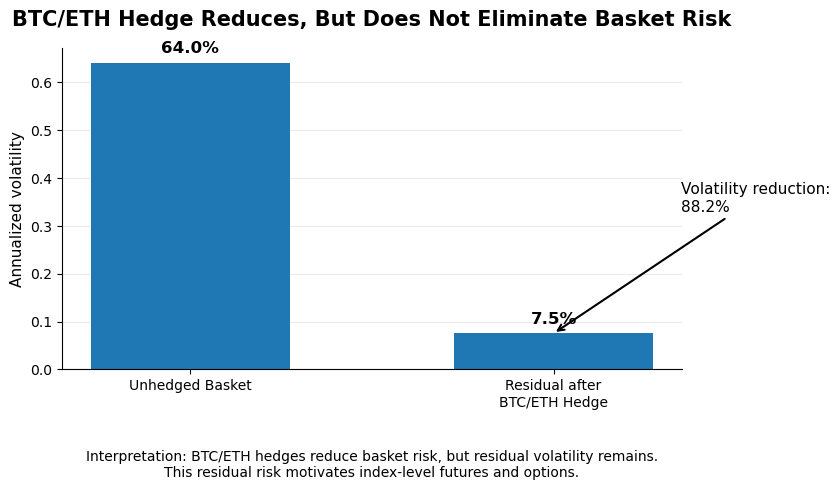

In [18]:
vol_compare = pd.DataFrame({
    "Annualized Volatility": [basket_vol, residual_vol]
}, index=["Unhedged Basket", "Residual after\nBTC/ETH Hedge"])

risk_reduction_pct = (1 - residual_vol / basket_vol) * 100

fig, ax = plt.subplots(figsize=(8.5, 5.2))

bars = ax.bar(
    vol_compare.index,
    vol_compare["Annualized Volatility"],
    width=0.55
)

ax.set_title(
    "BTC/ETH Hedge Reduces, But Does Not Eliminate Basket Risk",
    fontsize=15,
    fontweight="bold",
    pad=16
)

ax.set_ylabel("Annualized volatility", fontsize=11)

# Make chart cleaner
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

# Add values on bars
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.015,
        f"{height:.1%}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Add risk reduction annotation
ax.annotate(
    f"Volatility reduction:\n{risk_reduction_pct:.1f}%",
    xy=(1, residual_vol),
    xytext=(1.35, (basket_vol + residual_vol) / 2),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11,
    ha="left",
    va="center"
)

# Add interpretation text
ax.text(
    0.5,
    -0.25,
    "Interpretation: BTC/ETH hedges reduce basket risk, but residual volatility remains.\nThis residual risk motivates index-level futures and options.",
    transform=ax.transAxes,
    ha="center",
    va="top",
    fontsize=10
)

plt.tight_layout()

plt.savefig(
    "btc_eth_hedge_residual_risk_ppt.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()